In [2]:
import pandas as pd 
import os 
import pathlib
# pd.set_option("display.max_rows", 100)

import matplotlib.pylab as pylt
pylt.rcParams['figure.dpi'] = 200
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline

from sudulunu.helpers import pp, make_num, dumper

In [3]:
# ### Monthly average patronage on Vic rail by day
# data = pd.read_csv('input/Monthly average patronage by day type and by mode.csv')
# # ['Year', 'Month', 'Month_name', 'Day_of_week', 'Day_type', 'Mode', 'Pax_daily']

# data['Date'] = data['Year'].astype(str) + "/" + data['Month'].astype(str)

# data['Date'] = pd.to_datetime(data['Date'], format='%Y/%m')

# # pp(data)

# for col in ['Pax_daily']:
#     data[col] = pd.to_numeric(data[col])

# grp = data.groupby(by=['Date', 'Day_type'])['Pax_daily'].mean().reset_index()


# sns.lineplot(grp, x='Date', y='Pax_daily', hue='Day_type')

<Axes: xlabel='census_year', ylabel='dwelling_number'>

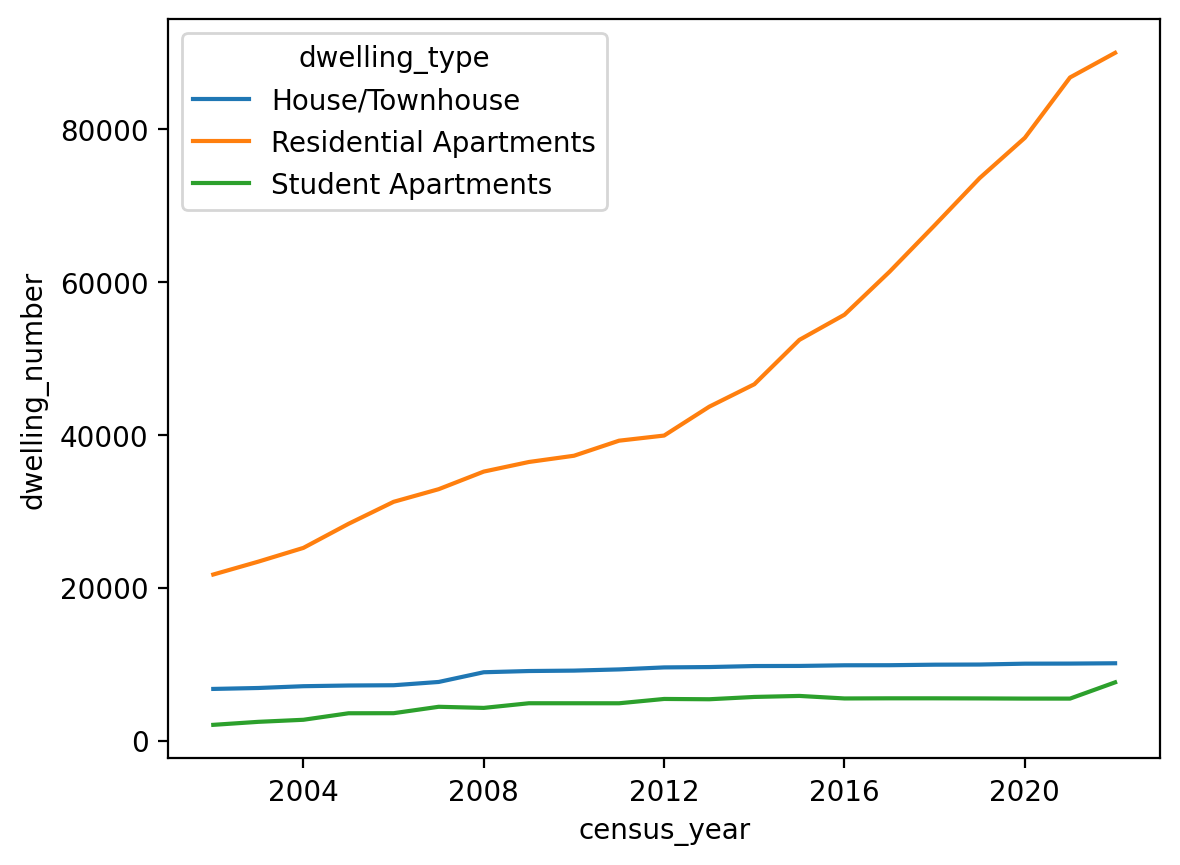

In [4]:
### Number of residential dwellings in Melbourne CBD

# from the City of Melb CLUE database:
# https://data.melbourne.vic.gov.au/explore/dataset/residential-dwellings/export/

data = pd.read_csv('input/residential-dwellings.csv')
# ['census_year', 'block_id', 'property_id', 'base_property_id', 
# 'building_address', 'clue_small_area', 'dwelling_type', 'dwelling_number', 
# 'longitude', 'latitude', 'location']

grp = data.groupby(by=['census_year', 'dwelling_type'])['dwelling_number'].sum().reset_index()

grp['census_year'] = pd.to_datetime(grp['census_year'], format='%Y')

sns.lineplot(grp, x='census_year', y='dwelling_number', hue='dwelling_type')


In [5]:
# # Based on the Vic rental report 
# # https://discover.data.vic.gov.au/dataset/rental-report-quarterly-data-tables

# fillo = 'input/Tables from Rent Report - March quarter 2024.xlsx'
# # data = pd.read_excel(fillo, None).keys()
# # dict_keys(['Contents', 'Front page', 'Figure 1', 'Table 1', 'Table 2', 
# # 'Table 3', 'Figure 2', 'Figure 3', 'Table 4', 'Table 5', 'Table 6', 
# # 'Figure 4', 'Figure 5a', 'Figure 5b', 'Table 7', 'Table 8', 'Figure 6', 
# # 'Figure 7', 'Figure 8', 'Table 9', 'Table 10', 'Table 11', 'Figure 9a', 
# # 'Figure 9b', 'Table 12', 'Table 13', 'Table 14', 'Table 15', 'Fig 1 source', 
# # 'Fig 4 source', 'Fig 6 source', 'Fig 7 source', 'Fig 8 source'])

# data = pd.read_excel(fillo, sheet_name='Fig 6 source', skiprows=1)
# # ['Quarter', 'Lending to investors ($m)', 'Investor share of all housing loans (%)', 
# # 'Unnamed: 3', 'Unnamed: 4']
# data = data[['Quarter', 'Lending to investors ($m)', 'Investor share of all housing loans (%)']]

# data.rename(columns={'Quarter':"Date", 
#                      'Lending to investors ($m)': "Investors $M", 
#                      'Investor share of all housing loans (%)': "Investor share"}, inplace=True)

# data = data[:21]

# data["Investor share"] = data["Investor share"] * 100
# # sns.lineplot(data, x='Date', y="Investor share")
# sns.lineplot(data, x='Date', y="Investors $M")

<Axes: xlabel='Date', ylabel='value'>

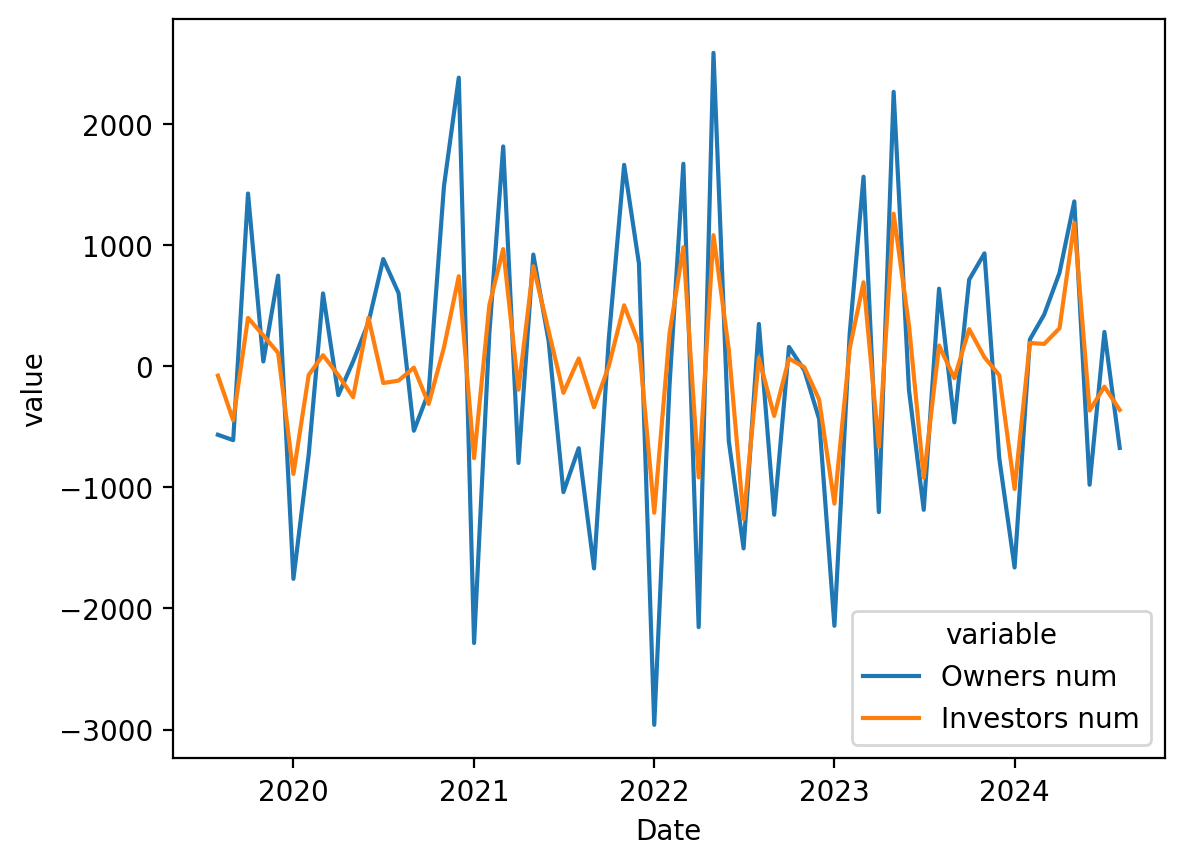

In [28]:
### ABS owner occupiers vs investors lending data
# https://www.abs.gov.au/statistics/economy/finance/lending-indicators/latest-release#data-downloads

owns = pd.read_excel('input/560106.xlsx', sheet_name='Data1')
owns = owns[['Unnamed: 0', 'Households ;  Housing Finance ;  Owner occupier ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Number ;', 'Households ;  Housing Finance ;  Owner occupier ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Value ;']]
owns.rename(columns={'Unnamed: 0': "Date",
                     'Households ;  Housing Finance ;  Owner occupier ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Number ;': "Owners num",
                     'Households ;  Housing Finance ;  Owner occupier ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Value ;': 'Owners $'}, inplace=True)
owns = owns[10:]
owns.dropna(inplace=True)

owns['Date'] = pd.to_datetime(owns['Date']).dt.strftime("%Y-%m-%d")

invs = pd.read_excel('input/560116.xlsx', sheet_name='Data1')

invs = invs[['Unnamed: 0','Households ;  Housing Finance ;  Investor ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Number ;',
             'Households ;  Housing Finance ;  Investor ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Value ;']]

invs.rename(columns={'Unnamed: 0': "Date",
                     'Households ;  Housing Finance ;  Investor ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Number ;': "Investors num",
             'Households ;  Housing Finance ;  Investor ;  Total housing excluding refinancing ;  Victoria ;  New loan commitments ;  Value ;': "Investors $"}, inplace=True)

invs = invs[10:]
invs.dropna(inplace=True)

invs['Date'] = pd.to_datetime(invs['Date']).dt.strftime("%Y-%m-%d")

tog = pd.merge(owns, invs, on='Date', how='left')

### First one
# tog['Gap'] = tog['Owners num'] - tog['Investors num']
# tog['Date'] = pd.to_datetime(tog['Date'])
# sns.lineplot(tog, x='Date', y='Gap')

for col in ['Owners num','Investors num']:
    tog[col]  = pd.to_numeric(tog[col] )
    tog[col] = tog[col].diff()

melted = pd.melt(tog, id_vars='Date', value_vars=['Owners num',  'Investors num'])
melted['Date'] = pd.to_datetime(melted['Date'])
sns.lineplot(melted, x='Date', y='value', hue='variable')


### Third one
# for thingo in ['Owners num', 'Owners $', 'Investors num', 'Investors $']:
#     tog[thingo] = pd.to_numeric(tog[thingo])
#     tog[thingo] = round((tog[thingo] / tog[thingo].max())*100, 2)

# pp(tog)

# melted = pd.melt(tog, id_vars='Date', value_vars=['Owners num', 'Owners $', 'Investors num', 'Investors $'])

# # pp(melted)

# # melted = melted.loc[melted['variable'].isin(['Owners num', 'Investors num'])]
# melted = melted.loc[melted['variable'].isin(['Owners $',  'Investors $'])]

# melted['Date'] = pd.to_datetime(melted['Date'])

# sns.lineplot(melted, x='Date', y='value', hue='variable')
